<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Median_Household_Income.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Retrieving Census tracts for the entire United States


/tmp/ipykernel_810/1674612244.py:52: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  alaska_data = alaska_data[alaska_data.geometry.centroid.x < 0]


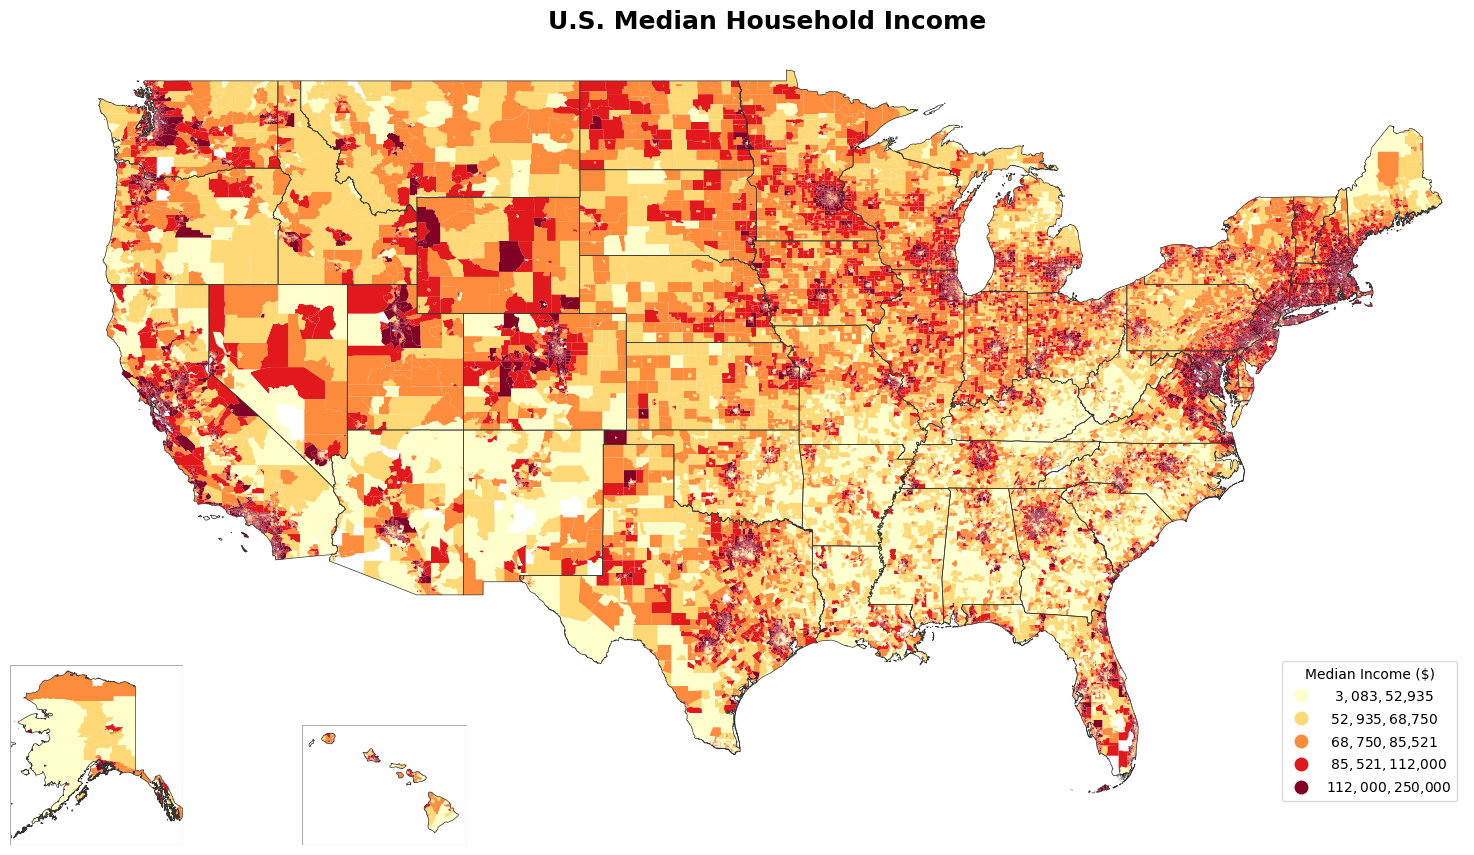

In [3]:
from matplotlib import legend
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from shapely.geometry import box
!pip install geodatasets
import geodatasets
!pip install pygris
import pygris


census = pd.read_csv("/content/ACSST5Y2024.S1901-Data.csv", header=1)

census["TRACT_GEOID"] = (census["Geography"].astype(str).str.split("US").str[-1].str.strip())

median_cols = [c for c in census.columns if "Estimate" in c and "Median income" in c and "Margin of Error" not in c]
TARGET_COLUMN = (median_cols[0] if len(median_cols) > 0 else "Estimate!!Households!!Total")
legend_title = "Median Income ($)" if len(median_cols) > 0 else "Total Households"

census["Data_Value"] = (census[TARGET_COLUMN].astype(str).str.replace(",", ""))
census["Data_Value"] = pd.to_numeric(census["Data_Value"], errors="coerce")

geo = pygris.tracts(state=None, cb=True, year=2022, cache=True)
geo["geoid_clean"] = geo["GEOID"].astype(str).str.strip()

state_borders = pygris.states(cb=True, year=2022, cache=True)

# merge
merged = geo.merge(census, left_on="geoid_clean", right_on="TRACT_GEOID", how="inner")
plot_data = merged.dropna(subset=["Data_Value"])

# maps

fig, ax_mainus = plt.subplots(figsize=(18, 10))

# hawaii shift
ax_alaska = fig.add_axes([0.05, 0.08, 0.18, 0.18])
ax_hawaii = fig.add_axes([0.24, 0.08, 0.12, 0.12])

# fips code
lower_48 = plot_data[~plot_data["STATEFP"].isin(["02", "15"])]
lower_48_borders = state_borders[~state_borders["STATEFP"].isin(["02", "15", "60", "66", "69", "72", "78"])]

alaska_data = plot_data[plot_data["STATEFP"] == "02"]
alaska_border = state_borders[state_borders["STATEFP"] == "02"]

# no western islands
alaska_data = alaska_data[alaska_data.geometry.centroid.x < 0]

hawaii_data = plot_data[plot_data["STATEFP"] == "15"]
hawaii_border = state_borders[state_borders["STATEFP"] == "15"]

# us
lower_48.plot(column="Data_Value", cmap="YlOrRd", scheme="Quantiles", k=5,legend=True, legend_kwds={"title": legend_title,
                                                                                                    "loc": "lower right",
                                                                                                    "fmt": "${:,.0f}",
                                                                                                    "frameon": True,
                                                                                                    "edgecolor": "lightgray" },ax=ax_main, linewidth=0.0, edgecolor="none",)lower_48_borders.plot(ax=ax_main, facecolor="none", edgecolor="#333333", linewidth=0.5)

# alaska
alaska_data.plot(column="Data_Value", cmap="YlOrRd", scheme="Quantiles", k=5,ax=ax_ak, linewidth=0.0, edgecolor="none", legend=False)
alaska_border.plot(ax=ax_alaska, facecolor="none", edgecolor="#333333", linewidth=0.5)

# hawaii
hawaii_data.plot(column="Data_Value", cmap="YlOrRd", scheme="Quantiles", k=5,ax=ax_hawaii, linewidth=0.0, edgecolor="none", legend=False)
hawaii_border.plot(ax=ax_hi, facecolor="none", edgecolor="#333333", linewidth=0.5)

ax_mainus.set_xlim(-126, -66)
ax_mainus.set_ylim(24, 50)
ax_mainus.axis("off")

ax_alaska.set_xlim(-170, -130)
ax_alaska.set_ylim(52, 72)
ax_alaska.axis("off")

ax_hawaii.set_xlim(-160.5, -154.5)
ax_hawaii.set_ylim(18.5, 22.5)
ax_hawaii.axis("off")

# border
alaska = plt.Rectangle((0,0), 1, 1, facecolor="none", edgecolor="#b0b0b0", linewidth=0.8, transform=ax_ak.transAxes)
hawaii = plt.Rectangle((0,0), 1, 1, facecolor="none", edgecolor="#b0b0b0", linewidth=0.8, transform=ax_hi.transAxes)
ax_alaska.add_patch(alaska)
ax_hawaii.add_patch(hawaii)

ax_main.set_title("U.S. Median Household Income", fontsize=18, fontweight="bold", y=1.02)

plt.show()

